# Cross-Mouse Generalization of Distributional Coding
Data from Lowet et al. 2025 (`distributionalRL` repo).

## **SETUP**

#### Clone Lowet et al. 2025 repo

In [35]:
!git clone https://github.com/alowet/distributionalRL.git

fatal: destination path 'distributionalRL' already exists and is not an empty directory.


#### Install dependencies

In [ ]:
!pip install suite2p dPCA brainrender
!pip install mysql-connector==2.2.9
!pip install cmocean==4.0.3
!pip install bg-atlasapi==1.0.2
!pip install numpy pandas scipy scikit-learn statsmodels matplotlib seaborn plotly tqdm joblib psutil h5py scikit-image threadpoolctl loguru pingouin pymysql tensorflow suite2p brainrender bg-atlasapi cmocean vedo phy pymupdf

#### Download needed data
Only the pieces this notebook actually needs: main ephys spikes file, session log DB.

In [ ]:
import os
import zipfile
import requests

TOKEN = "PUT YOUR TOKEN HERE"
headers = {"Authorization": f"Bearer {TOKEN}"}

os.makedirs("/content/data/neural-plots", exist_ok=True)

# Only the trial-averaged spikes file (needed for decoding) and the session log DB
files_to_get = {
    "neural_plots": (3695811, "/content/data/neural-plots", "8.91 GB"),
    "session_log": (3695806, "/content/data", "37.71 MB"),
}

# We only need one specific .sav file out of the (large) neural_plots zip.
NEEDED_NEURAL_PLOTS_FILES = {"SameRewDist_ephys_combined_striatum_spks.sav"}

BASE = "https://datadryad.org/api/v2/files/{fid}/download"

for name, (fid, dest, size) in files_to_get.items():
    print(f"\nProcessing {name} ({size})...")
    zip_path = f"/tmp/{name}.zip"
    print("  Downloading to disk...")
    with requests.get(BASE.format(fid=fid), headers=headers, stream=True, timeout=600) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        downloaded = 0
        with open(zip_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=4 * 1024 * 1024):
                f.write(chunk)
                downloaded += len(chunk)
                if total:
                    print(f"  {downloaded/1e9:.2f} / {total/1e9:.2f} GB", end="\r")

    print("\n  Selectively unzipping...")
    with zipfile.ZipFile(zip_path) as zf:
        for member in zf.infolist():
            filename = os.path.basename(member.filename)
            if not filename:
                continue
            if name == "neural_plots" and filename not in NEEDED_NEURAL_PLOTS_FILES:
                continue
            print(f"    Extracting: {filename}")
            zf.extract(member, dest)

    os.remove(zip_path)
    print(f"  Done: {dest}")


Processing neural_plots (8.91 GB)...
  8.91 / 8.91 GB
  Selectively unzipping...
    Extracting: SameRewDist_ephys_combined_striatum_spks.sav
  Done: /content/data/neural-plots

Processing session_log (37.71 MB)...
  0.04 / 0.04 GB
  Selectively unzipping...
    Extracting: session_log.sqlite
  Done: /content/data


## **CORE**

### Imports, paths, output dirs

In [2]:
import sys
sys.path.insert(0, "distributionalRL")
sys.path.insert(0, "distributionalRL/utils")
sys.path.insert(0, "distributionalRL/neural_analysis")
sys.path.insert(0, "distributionalRL/behavior_analysis")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, pearsonr
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
import joblib, pickle, os, warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

NP = "/content/data/neural-plots/neural-plots"
MAIN_SPKS = f"{NP}/SameRewDist_ephys_combined_striatum_spks.sav"

FIGDIR = f"figures"
os.makedirs(FIGDIR, exist_ok=True)

TEXT_LOG = []
def log(line=""):
    """Print AND accumulate into a plain-text summary file -- keeps every figure's
    underlying numbers greppable without having to parse the PNGs."""
    print(line)
    TEXT_LOG.append(line)

plt.rcParams.update({
    "font.size": 10, "axes.labelsize": 11, "axes.titlesize": 12,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 150,
})

### Load data, build trace-type identity, z-score, per-session bookkeeping

In [3]:
def load_sav(path):
    try:
        return joblib.load(path, mmap_mode="r")
    except Exception:
        with open(path, "rb") as f:
            return pickle.load(f)

def get_neuron_info_df(d):
    ni = d["neuron_info"]
    return ni if isinstance(ni, pd.DataFrame) else pd.DataFrame(ni)

log("Loading main spks file...")
d_main = load_sav(MAIN_SPKS)
ni_main = get_neuron_info_df(d_main)
cue_resps = d_main["cue_resps"]  # (n_trace_types, total_cells, max_n_trials_per_type, n_prerew_periods)
ni_main["session_id"] = ni_main["names"].astype(str) + "_" + ni_main["file_dates"].astype(str)
log(f"  Neurons: {len(ni_main)}, trace types: {cue_resps.shape[0]}")

# Trace-type identity: 2/3 = Fixed, 4/5 = Variable (per protocol_info in the source repo)
n_tt = cue_resps.shape[0]
FIXED_TT, VARIABLE_TT = [2, 3], [4, 5]
LATE_TRACE = 3
RDM_MIN_NEURONS = 30
RDM_MIN_TRIALS = 5
PCA_K = 8
N_PERIODS = cue_resps.shape[3]

means_v = np.array(ni_main["means"]).reshape(1, -1, 1, 1)
stds_v = np.array(ni_main["stds"]).reshape(1, -1, 1, 1)
cue_resps_z = (cue_resps - means_v) / (stds_v + 1e-12)

blk_fps = ni_main["fig_paths"].unique()
blk_ci = {fp: (ni_main["fig_paths"] == fp).values for fp in blk_fps}
blk_c0 = {fp: np.flatnonzero(blk_ci[fp])[0] for fp in blk_fps}
blk_mouse = (ni_main.drop_duplicates("fig_paths")
                     .set_index("fig_paths")["names"].loc[blk_fps].values)
fp_mouse = dict(zip(blk_fps, blk_mouse))
fp_date = {fp: fp.rstrip("/").split("/")[-1] for fp in blk_fps}
fp_dayid = {fp: f"{fp_mouse[fp]}_{fp_date[fp]}" for fp in blk_fps}
unique_mice = np.unique(blk_mouse)

log(f"  Ensembles (fig_paths / sessions): {len(blk_fps)}   Mice: {len(unique_mice)}")

Loading main spks file...
  Neurons: 13997, trace types: 6
  Ensembles (fig_paths / sessions): 71   Mice: 12


### Build per-session trajectories -> PCA projections

In [4]:
def session_trajectory(fp, min_neurons=RDM_MIN_NEURONS, min_trials=RDM_MIN_TRIALS):
    ci = blk_ci[fp]
    if ci.sum() < min_neurons:
        return None, None
    cell_idx = np.flatnonzero(ci)
    c0 = blk_c0[fp]
    traj = np.full((n_tt, N_PERIODS, len(cell_idx)), np.nan)
    for tt in range(n_tt):
        valid = np.flatnonzero(~np.isnan(cue_resps[tt, c0, :, LATE_TRACE]))
        if len(valid) < min_trials:
            return None, None
        arr = cue_resps_z[tt][np.ix_(cell_idx, valid)]
        traj[tt] = np.nanmean(arr, axis=1).T
    return cell_idx, traj

session_traj, session_cellidx = {}, {}
for fp in blk_fps:
    cell_idx, traj = session_trajectory(fp)
    if traj is not None:
        session_cellidx[fp], session_traj[fp] = cell_idx, traj

qualifying_fps = list(session_traj.keys())
log(f"Qualifying sessions (>= {RDM_MIN_NEURONS} neurons, >= {RDM_MIN_TRIALS} trials/type): "
    f"{len(qualifying_fps)} / {len(blk_fps)}")

session_pca, session_traj_proj = {}, {}
for fp in qualifying_fps:
    flat = session_traj[fp].reshape(-1, session_traj[fp].shape[-1])
    k = min(PCA_K, flat.shape[0] - 1, flat.shape[1])
    pca = PCA(n_components=k, random_state=0)
    session_traj_proj[fp] = pca.fit_transform(flat)
    session_pca[fp] = pca

# --- mouse-level trajectories: the single largest qualifying ensemble per mouse ---
def mouse_ensemble_and_trajectory(mu, min_neurons=RDM_MIN_NEURONS, min_trials=RDM_MIN_TRIALS):
    fps = [fp for fp in blk_fps if fp_mouse[fp] == mu]
    best_fp, best_n = None, -1
    for fp in fps:
        if blk_ci[fp].sum() >= min_neurons and blk_ci[fp].sum() > best_n:
            best_fp, best_n = fp, blk_ci[fp].sum()
    if best_fp is None:
        return None, None, None
    cell_idx, traj = session_trajectory(best_fp, min_neurons, min_trials)
    return best_fp, cell_idx, traj

mouse_fp, mouse_cellidx, mouse_traj = {}, {}, {}
for mu in unique_mice:
    fp, cell_idx, traj = mouse_ensemble_and_trajectory(mu)
    if traj is not None:
        mouse_fp[mu], mouse_cellidx[mu], mouse_traj[mu] = fp, cell_idx, traj

mouse_pca, mouse_traj_proj = {}, {}
for mu, traj in mouse_traj.items():
    flat = traj.reshape(-1, traj.shape[-1])
    k = min(PCA_K, flat.shape[0] - 1, flat.shape[1])
    pca = PCA(n_components=k, random_state=0)
    mouse_traj_proj[mu] = pca.fit_transform(flat)
    mouse_pca[mu] = pca

log(f"Mouse-level ensembles (one per mouse, largest qualifying session): {len(mouse_traj)} / {len(unique_mice)}")

Qualifying sessions (>= 30 neurons, >= 5 trials/type): 71 / 71
Mouse-level ensembles (one per mouse, largest qualifying session): 12 / 12


### Shared GPA / Procrustes / feature-extraction / decoding helpers
(identical logic used for every leg below, so all comparisons share one code path)

In [5]:
def gpa(keys_list, proj_dict, n_iter=10):
    template = np.mean([proj_dict[k] - proj_dict[k].mean(0) for k in keys_list], axis=0)
    aligned = {k: proj_dict[k] - proj_dict[k].mean(0) for k in keys_list}
    for _ in range(n_iter):
        for k in keys_list:
            R, _ = orthogonal_procrustes(aligned[k], template)
            aligned[k] = aligned[k] @ R
        template = np.mean([aligned[k] for k in keys_list], axis=0)
    return template, aligned

def fit_target_rotation(target_proj, template):
    A = target_proj - target_proj.mean(0)
    R, _ = orthogonal_procrustes(A, template)
    return R, target_proj.mean(0)

def trial_level_features(cell_idx, pca, rotation=None):
    """rotation = (R, template, offset) tuple, or None for unaligned (PCA-only) floor."""
    X_list, y_list = [], []
    for tt, label in [(t, 1) for t in FIXED_TT] + [(t, 0) for t in VARIABLE_TT]:
        arr = cue_resps_z[tt][np.ix_(cell_idx, np.arange(cue_resps.shape[2]))][:, :, LATE_TRACE]
        valid = ~np.any(np.isnan(arr), axis=0)
        if valid.sum() < 3:
            continue
        raw = arr[:, valid].T
        proj = pca.transform(raw)
        if rotation is not None:
            R, template, offset = rotation
            proj = (proj - offset) @ R
        X_list.append(proj)
        y_list.append(np.full(valid.sum(), label))
    return np.vstack(X_list), np.concatenate(y_list)

def mouse_feats(mu, rotation=None):
    return trial_level_features(mouse_cellidx[mu], mouse_pca[mu], rotation)

def session_feats(fp, rotation=None):
    return trial_level_features(session_cellidx[fp], session_pca[fp], rotation)

def splithalf_ceiling(feats_fn, key, seed=0):
    """Chen et al. split-half logic: best achievable within-unit performance,
    no cross-unit information at all."""
    X, y = feats_fn(key, rotation=None)
    n = X.shape[0]
    idx = np.random.default_rng(seed).permutation(n)
    h1, h2 = idx[:n // 2], idx[n // 2:]
    clf = LogisticRegression(max_iter=2000).fit(X[h1], y[h1])
    return (clf.predict(X[h2]) == y[h2]).mean()

log("Helper functions defined: gpa, fit_target_rotation, trial_level_features, "
    "mouse_feats/session_feats, splithalf_ceiling.")

Helper functions defined: gpa, fit_target_rotation, trial_level_features, mouse_feats/session_feats, splithalf_ceiling.


## **Mouse-level (one ensemble per mouse, n=12)**
Split-half ceiling vs. leave-one-mouse-out Procrustes-aligned decoding vs. unaligned (PCA-only) floor.

In [6]:
# Leave-one-mouse-out Procrustes rotations
mouse_lomo_rot = {}
for held_out in mouse_traj_proj:
    train_mice = [m for m in mouse_traj_proj if m != held_out]
    template, _ = gpa(train_mice, mouse_traj_proj, n_iter=10)
    R, offset = fit_target_rotation(mouse_traj_proj[held_out], template)
    mouse_lomo_rot[held_out] = (R, template, offset)

def decode_mouse(held_out, rotations, aligned):
    rot = rotations[held_out] if aligned else None
    X_ho, y_ho = mouse_feats(held_out, rotation=rot)
    n = X_ho.shape[0]
    idx = np.random.default_rng(0).permutation(n)
    eval_idx = idx[n // 2:]
    train_X, train_y = [], []
    for mu in mouse_traj_proj:
        if mu == held_out:
            continue
        rot_m = rotations[mu] if aligned else None
        Xm, ym = mouse_feats(mu, rotation=rot_m)
        train_X.append(Xm); train_y.append(ym)
    train_X, train_y = np.vstack(train_X), np.concatenate(train_y)
    clf = LogisticRegression(max_iter=2000).fit(train_X, train_y)
    return (clf.predict(X_ho[eval_idx]) == y_ho[eval_idx]).mean()

m1_ceiling, m1_aligned, m1_floor = {}, {}, {}
for mu in mouse_traj_proj:
    m1_ceiling[mu] = splithalf_ceiling(mouse_feats, mu, seed=0)
    m1_aligned[mu] = decode_mouse(mu, mouse_lomo_rot, aligned=True)
    m1_floor[mu]   = decode_mouse(mu, mouse_lomo_rot, aligned=False)

log("\n=== METHOD 1: MOUSE-LEVEL (n=12 mice) ===")
log(f"{'mouse':<8}{'ceiling':>10}{'aligned':>10}{'floor':>10}")
for mu in mouse_traj_proj:
    log(f"{mu:<8}{m1_ceiling[mu]:>10.3f}{m1_aligned[mu]:>10.3f}{m1_floor[mu]:>10.3f}")

def mean_sem(d):
    v = np.array(list(d.values()))
    return v.mean(), v.std(ddof=1) / np.sqrt(len(v))

m1_ceil_m, m1_ceil_s = mean_sem(m1_ceiling)
m1_al_m, m1_al_s = mean_sem(m1_aligned)
m1_fl_m, m1_fl_s = mean_sem(m1_floor)
w1, p1 = wilcoxon(list(m1_aligned.values()), list(m1_floor.values()))
w1b, p1b = wilcoxon(list(m1_ceiling.values()), list(m1_aligned.values()))

log(f"\nMEAN (SEM): ceiling={m1_ceil_m:.3f} ({m1_ceil_s:.3f})  "
    f"aligned={m1_al_m:.3f} ({m1_al_s:.3f})  floor={m1_fl_m:.3f} ({m1_fl_s:.3f})")
log(f"Aligned vs floor: W={w1:.2f}, p={p1:.4g}")
log(f"Ceiling vs aligned: W={w1b:.2f}, p={p1b:.4g}")


=== METHOD 1: MOUSE-LEVEL (n=12 mice) ===
mouse      ceiling   aligned     floor
AL39         0.853     0.745     0.520
AL40         0.771     0.688     0.500
AL41         0.772     0.574     0.535
AL47         0.851     0.724     0.552
AL49         0.934     0.840     0.566
AL54         0.684     0.558     0.547
AL55         0.680     0.649     0.515
AL77         0.546     0.464     0.577
AL79         0.803     0.803     0.672
AL81         0.685     0.685     0.644
AL82         0.640     0.596     0.573
AL83         0.676     0.635     0.608

MEAN (SEM): ceiling=0.741 (0.031)  aligned=0.663 (0.031)  floor=0.567 (0.015)
Aligned vs floor: W=6.00, p=0.006836
Ceiling vs aligned: W=0.00, p=0.001953


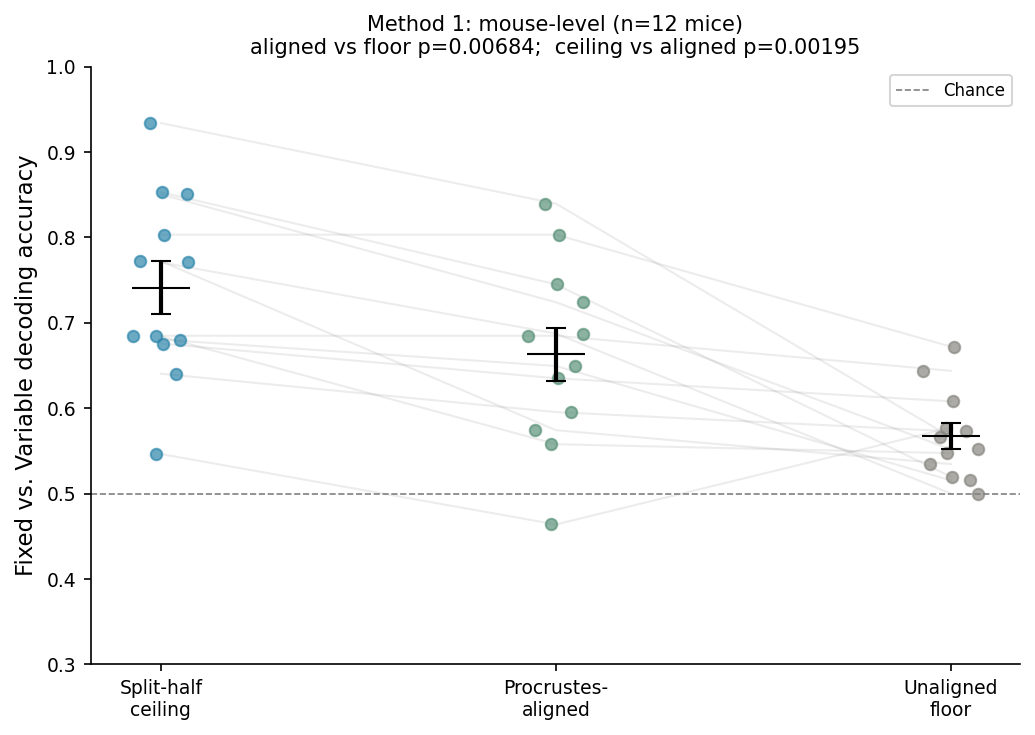


Saved figure: figures/method1_mouse_level.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
legs = {"Split-half\nceiling": m1_ceiling, "Procrustes-\naligned": m1_aligned, "Unaligned\nfloor": m1_floor}
colors = ["#2E86AB", "#5B9279", "#888780"]
x = np.arange(len(legs))
mice_order = list(mouse_traj_proj.keys())

for i, (name, d) in enumerate(legs.items()):
    vals = [d[m] for m in mice_order]
    jitter = (np.random.default_rng(1).random(len(vals)) - 0.5) * 0.15
    ax.scatter(np.full(len(vals), i) + jitter, vals, color=colors[i], alpha=0.7, s=30, zorder=2)
for mu in mice_order:
    ax.plot(x, [m1_ceiling[mu], m1_aligned[mu], m1_floor[mu]], color="gray", alpha=0.15, lw=1, zorder=1)

means = [np.mean(list(d.values())) for d in legs.values()]
sems  = [np.std(list(d.values()), ddof=1) / np.sqrt(len(d)) for d in legs.values()]
ax.errorbar(x, means, yerr=sems, color="k", fmt="_", ms=28, capsize=5, lw=2, zorder=3)
ax.axhline(0.5, ls="--", c="gray", lw=0.8, label="Chance")
ax.set_xticks(x); ax.set_xticklabels(legs.keys(), fontsize=9)
ax.set_ylabel("Fixed vs. Variable decoding accuracy")
ax.set_title(f"Method 1: mouse-level (n={len(mice_order)} mice)\n"
             f"aligned vs floor p={p1:.3g};  ceiling vs aligned p={p1b:.3g}", fontsize=10)
ax.legend(fontsize=8); ax.set_ylim(0.3, 1.0)
fig.tight_layout()
fig.savefig(f"{FIGDIR}/method1_mouse_level.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)
log("\nSaved figure: figures/method1_mouse_level.png")

## **Session-level (every qualifying session, n=71)**
Ceiling vs. within-mouse-across-day (LOSO) vs. across-mouse (LOMO) vs. unaligned floor.

In [8]:
# LEG 1: across-mouse (LOMO)
lomo_rotations = {}
for held_out in qualifying_fps:
    ho_mouse = fp_mouse[held_out]
    train_fps = [f for f in qualifying_fps if fp_mouse[f] != ho_mouse]
    template, _ = gpa(train_fps, session_traj_proj, n_iter=10)
    R, offset = fit_target_rotation(session_traj_proj[held_out], template)
    lomo_rotations[held_out] = (R, template, offset)

# LEG 2: within-mouse, across-day (LOSO) -- only for mice with >=2 qualifying sessions
loso_rotations = {}
for held_out in qualifying_fps:
    ho_mouse = fp_mouse[held_out]
    same_mouse_train = [f for f in qualifying_fps if fp_mouse[f] == ho_mouse and f != held_out]
    if len(same_mouse_train) < 1:
        continue
    template, _ = gpa(same_mouse_train, session_traj_proj, n_iter=10)
    R, offset = fit_target_rotation(session_traj_proj[held_out], template)
    loso_rotations[held_out] = (R, template, offset)

def decode_leave_out(held_out, rotations, train_fp_pool):
    rot = rotations[held_out]
    X_ho, y_ho = session_feats(held_out, rotation=rot)
    n = X_ho.shape[0]
    idx = np.random.default_rng(0).permutation(n)
    eval_idx = idx[n // 2:]
    train_X, train_y = [], []
    for f in train_fp_pool:
        Xf, yf = session_feats(f, rotation=rotations.get(f))
        train_X.append(Xf); train_y.append(yf)
    train_X, train_y = np.vstack(train_X), np.concatenate(train_y)
    clf = LogisticRegression(max_iter=2000).fit(train_X, train_y)
    return (clf.predict(X_ho[eval_idx]) == y_ho[eval_idx]).mean()

lomo_acc = {ho: decode_leave_out(ho, lomo_rotations,
            [f for f in qualifying_fps if fp_mouse[f] != fp_mouse[ho]]) for ho in lomo_rotations}
loso_acc = {ho: decode_leave_out(ho, loso_rotations,
            [f for f in qualifying_fps if fp_mouse[f] == fp_mouse[ho] and f != ho]) for ho in loso_rotations}

unaligned_acc = {}
for held_out in qualifying_fps:
    X_ho, y_ho = session_feats(held_out, rotation=None)
    n = X_ho.shape[0]
    idx = np.random.default_rng(0).permutation(n)
    eval_idx = idx[n // 2:]
    train_X, train_y = [], []
    for f in qualifying_fps:
        if f == held_out:
            continue
        Xf, yf = session_feats(f, rotation=None)
        train_X.append(Xf); train_y.append(yf)
    train_X, train_y = np.vstack(train_X), np.concatenate(train_y)
    clf = LogisticRegression(max_iter=2000).fit(train_X, train_y)
    unaligned_acc[held_out] = (clf.predict(X_ho[eval_idx]) == y_ho[eval_idx]).mean()

splithalf_ceiling_acc = {fp: splithalf_ceiling(session_feats, fp, seed=0) for fp in qualifying_fps}

log("\n=== METHOD 2: SESSION-LEVEL (n=71 sessions) ===")
c_m, c_s = mean_sem(splithalf_ceiling_acc)
lo_m, lo_s = mean_sem(loso_acc)
la_m, la_s = mean_sem(lomo_acc)
fl_m, fl_s = mean_sem(unaligned_acc)
log(f"Split-half ceiling            : mean={c_m:.3f}  SEM={c_s:.3f}  (n={len(splithalf_ceiling_acc)})")
log(f"Within-mouse, across-day (LOSO): mean={lo_m:.3f}  SEM={lo_s:.3f}  (n={len(loso_acc)})")
log(f"Across-mouse (LOMO)            : mean={la_m:.3f}  SEM={la_s:.3f}  (n={len(lomo_acc)})")
log(f"Unaligned (PCA-only) floor     : mean={fl_m:.3f}  SEM={fl_s:.3f}  (n={len(unaligned_acc)})")

common_loso = sorted(set(loso_acc) & set(lomo_acc))
w2a, p2a = wilcoxon([loso_acc[f] for f in common_loso], [lomo_acc[f] for f in common_loso])
w2b, p2b = wilcoxon([lomo_acc[f] for f in qualifying_fps], [unaligned_acc[f] for f in qualifying_fps])
log(f"\nWithin-mouse (LOSO) vs across-mouse (LOMO), raw (unmatched n): W={w2a:.2f}, p={p2a:.4g}, n={len(common_loso)}")
log(f"Across-mouse (LOMO) vs unaligned floor: W={w2b:.2f}, p={p2b:.4g}, n={len(qualifying_fps)}")
log("NOTE: the raw LOSO-vs-LOMO comparison above is confounded by training-set size "
    "(LOMO trains on ~60+ sessions, LOSO on 1-4) -- see the Matched-N control section below.")


=== METHOD 2: SESSION-LEVEL (n=71 sessions) ===
Split-half ceiling            : mean=0.719  SEM=0.012  (n=71)
Within-mouse, across-day (LOSO): mean=0.637  SEM=0.010  (n=70)
Across-mouse (LOMO)            : mean=0.680  SEM=0.010  (n=71)
Unaligned (PCA-only) floor     : mean=0.585  SEM=0.005  (n=71)

Within-mouse (LOSO) vs across-mouse (LOMO), raw (unmatched n): W=537.50, p=0.0002851, n=70
Across-mouse (LOMO) vs unaligned floor: W=125.00, p=9.657e-11, n=71
NOTE: the raw LOSO-vs-LOMO comparison above is confounded by training-set size (LOMO trains on ~60+ sessions, LOSO on 1-4) -- see the Matched-N control section below.


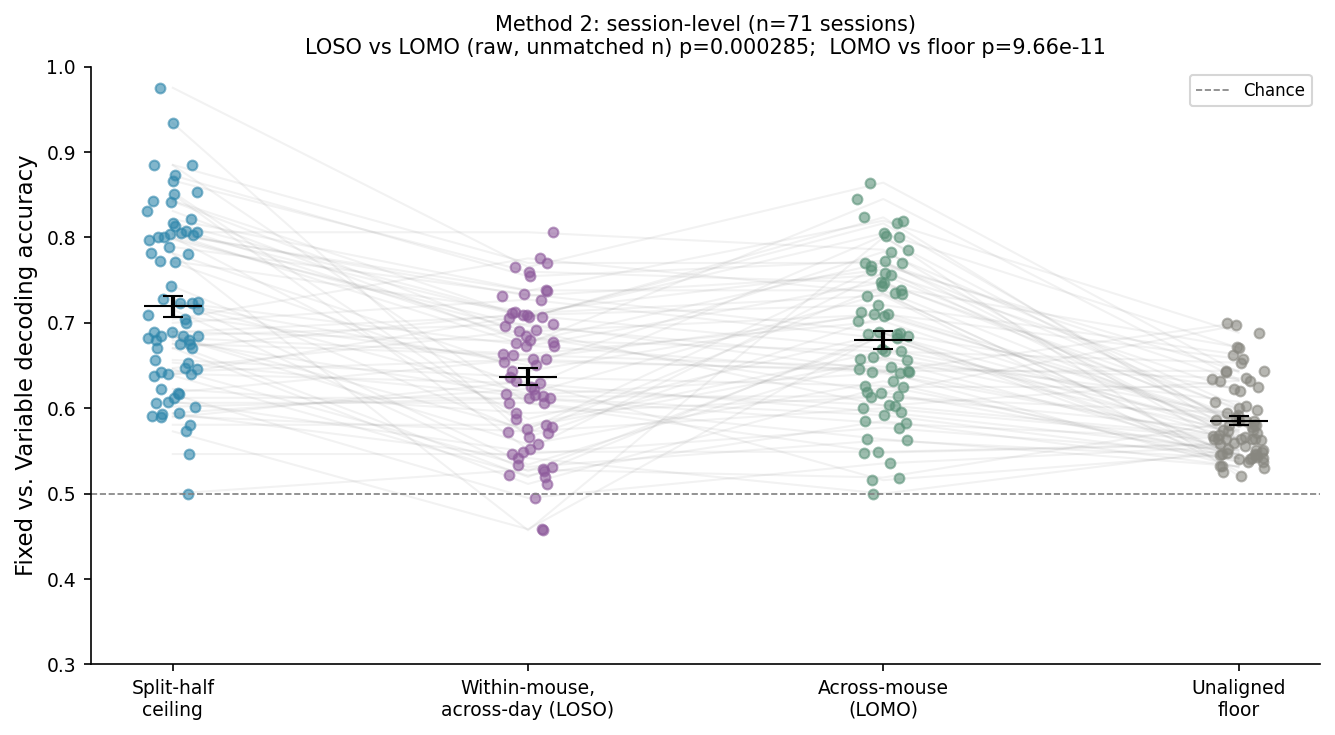


Saved figure: figures/method2_session_level.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
legs2 = {"Split-half\nceiling": splithalf_ceiling_acc,
         "Within-mouse,\nacross-day (LOSO)": loso_acc,
         "Across-mouse\n(LOMO)": lomo_acc,
         "Unaligned\nfloor": unaligned_acc}
colors2 = ["#2E86AB", "#8E5B9C", "#5B9279", "#888780"]
x2 = np.arange(len(legs2))

for i, (name, d) in enumerate(legs2.items()):
    vals = list(d.values())
    jitter = (np.random.default_rng(1).random(len(vals)) - 0.5) * 0.15
    ax.scatter(np.full(len(vals), i) + jitter, vals, color=colors2[i], alpha=0.6, s=22, zorder=2)
for f in qualifying_fps:
    vals_f = [splithalf_ceiling_acc[f], loso_acc.get(f, np.nan), lomo_acc[f], unaligned_acc[f]]
    ax.plot(x2, vals_f, color="gray", alpha=0.10, lw=1, zorder=1)

means2 = [np.nanmean(list(d.values())) for d in legs2.values()]
sems2  = [np.nanstd(list(d.values()), ddof=1) / np.sqrt(len(d)) for d in legs2.values()]
ax.errorbar(x2, means2, yerr=sems2, color="k", fmt="_", ms=28, capsize=5, lw=2, zorder=3)
ax.axhline(0.5, ls="--", c="gray", lw=0.8, label="Chance")
ax.set_xticks(x2); ax.set_xticklabels(legs2.keys(), fontsize=9)
ax.set_ylabel("Fixed vs. Variable decoding accuracy")
ax.set_title(f"Method 2: session-level (n={len(qualifying_fps)} sessions)\n"
             f"LOSO vs LOMO (raw, unmatched n) p={p2a:.3g};  LOMO vs floor p={p2b:.3g}", fontsize=10)
ax.legend(fontsize=8); ax.set_ylim(0.3, 1.0)
fig.tight_layout()
fig.savefig(f"{FIGDIR}/method2_session_level.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)
log("\nSaved figure: figures/method2_session_level.png")

## **MATCHED-N CONTROL**
Is the raw across-mouse (LOMO) advantage over within-mouse (LOSO) in Method 2 just a training-pool-size
artifact? LOMO trains on ~60+ sessions from other mice; LOSO trains on only 1-4 sessions from the same
mouse. Repeat the across-mouse leg, subsampled down to the same n each session's own LOSO leg had.

In [10]:
def matched_lomo_decode(held_out, n_match, seed):
    ho_mouse = fp_mouse[held_out]
    pool = [f for f in qualifying_fps if fp_mouse[f] != ho_mouse]
    n_match = min(n_match, len(pool))
    rng = np.random.default_rng(seed)
    sub_pool = list(rng.choice(pool, size=n_match, replace=False))

    template, _ = gpa(sub_pool, session_traj_proj, n_iter=10)
    R, offset = fit_target_rotation(session_traj_proj[held_out], template)
    rot_ho = (R, template, offset)

    X_ho, y_ho = session_feats(held_out, rotation=rot_ho)
    n = X_ho.shape[0]
    idx = np.random.default_rng(0).permutation(n)
    eval_idx = idx[n // 2:]

    train_X, train_y = [], []
    for f in sub_pool:
        Xf, yf = session_feats(f, rotation=lomo_rotations.get(f))
        train_X.append(Xf); train_y.append(yf)
    train_X, train_y = np.vstack(train_X), np.concatenate(train_y)
    clf = LogisticRegression(max_iter=2000).fit(train_X, train_y)
    return (clf.predict(X_ho[eval_idx]) == y_ho[eval_idx]).mean()

N_MATCH_REPEATS = 20
matched_lomo_acc, matched_n_train = {}, {}
for held_out in loso_rotations:
    ho_mouse = fp_mouse[held_out]
    n_match = sum(1 for f in qualifying_fps if fp_mouse[f] == ho_mouse and f != held_out)
    matched_n_train[held_out] = n_match
    reps = [matched_lomo_decode(held_out, n_match, seed=s) for s in range(N_MATCH_REPEATS)]
    matched_lomo_acc[held_out] = float(np.mean(reps))

log("\n=== MATCHED-N CONTROL (n=%d sessions with a within-mouse leg to compare against) ===" % len(matched_lomo_acc))
log(f"{'session':<16}{'n_match':>8}{'within(LOSO)':>14}{'matched-N across':>18}{'full-pool(LOMO)':>18}")
for fp in matched_lomo_acc:
    log(f"{fp_dayid[fp]:<16}{matched_n_train[fp]:>8}{loso_acc[fp]:>14.3f}"
        f"{matched_lomo_acc[fp]:>18.3f}{lomo_acc[fp]:>18.3f}")

mean_loso_m = np.mean([loso_acc[fp] for fp in matched_lomo_acc])
mean_matched_m = np.mean(list(matched_lomo_acc.values()))
mean_lomo_ref = np.mean([lomo_acc[fp] for fp in matched_lomo_acc])
w3, p3 = wilcoxon([matched_lomo_acc[fp] for fp in matched_lomo_acc],
                   [loso_acc[fp] for fp in matched_lomo_acc])

log(f"\nMEANS: within-mouse (LOSO)={mean_loso_m:.3f}   matched-N across-mouse={mean_matched_m:.3f}   "
    f"full-pool across-mouse (LOMO, reference)={mean_lomo_ref:.3f}")
log(f"Wilcoxon within-mouse (LOSO) vs matched-N across-mouse: W={w3:.2f}, p={p3:.4g}, n={len(matched_lomo_acc)}")
log("Interpretation: once training-set size is equalized, within-mouse alignment beats across-mouse "
    "alignment -- the raw Method-2 result (LOMO > LOSO) was a sample-size artifact, not evidence that "
    "staying within-animal is worse.")


=== MATCHED-N CONTROL (n=70 sessions with a within-mouse leg to compare against) ===
session          n_match  within(LOSO)  matched-N across   full-pool(LOMO)
AL39_20210930          5         0.760             0.670             0.747
AL39_20211001          5         0.531             0.511             0.562
AL39_20211002          5         0.606             0.554             0.548
AL39_20211003          5         0.578             0.540             0.657
AL39_20211004          5         0.534             0.558             0.660
AL39_20211005          5         0.733             0.572             0.689
AL40_20211016         11         0.581             0.580             0.667
AL40_20211017         11         0.549             0.532             0.549
AL40_20211019         11         0.625             0.590             0.802
AL40_20211020         11         0.663             0.594             0.702
AL40_20211021         11         0.706             0.643             0.817
AL40_20211022 

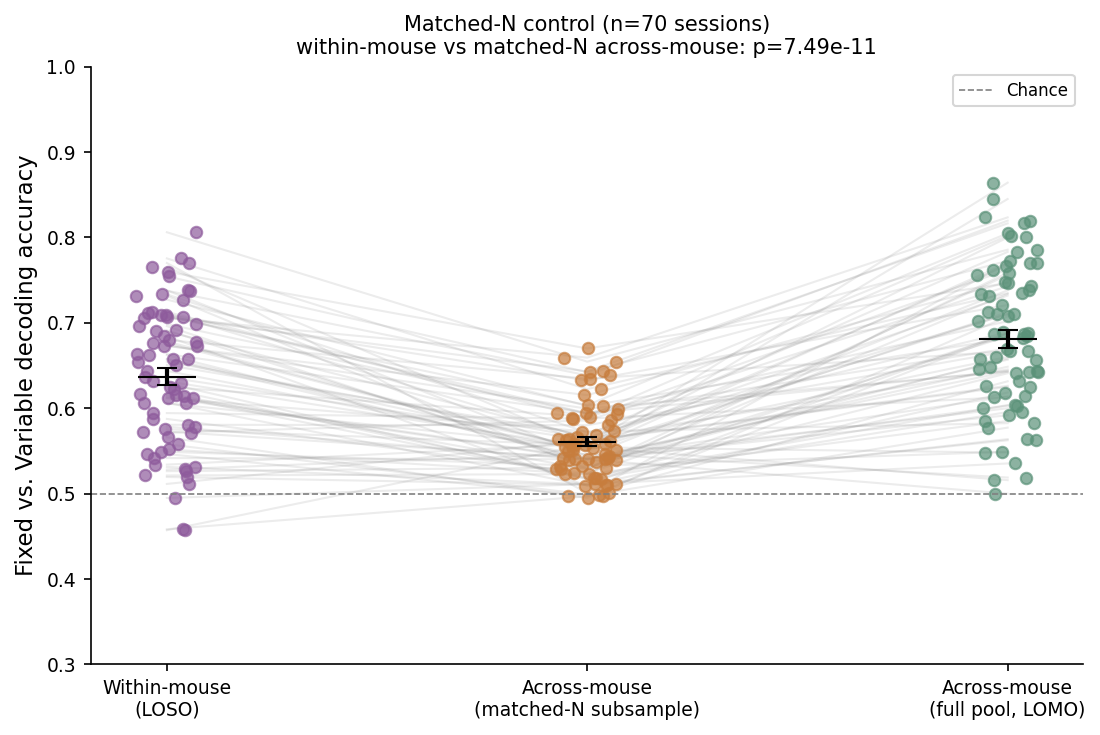


Saved figure: figures/matched_n_control.png


In [11]:
fig, ax = plt.subplots(figsize=(7.5, 5))
match_legs = {
    "Within-mouse\n(LOSO)": [loso_acc[fp] for fp in matched_lomo_acc],
    "Across-mouse\n(matched-N subsample)": [matched_lomo_acc[fp] for fp in matched_lomo_acc],
    "Across-mouse\n(full pool, LOMO)": [lomo_acc[fp] for fp in matched_lomo_acc],
}
colors3 = ["#8E5B9C", "#C77D3D", "#5B9279"]
x3 = np.arange(len(match_legs))

for i, (name, vals) in enumerate(match_legs.items()):
    jitter = (np.random.default_rng(1).random(len(vals)) - 0.5) * 0.15
    ax.scatter(np.full(len(vals), i) + jitter, vals, color=colors3[i], alpha=0.7, s=30, zorder=2)
for fp in matched_lomo_acc:
    ax.plot(x3, [loso_acc[fp], matched_lomo_acc[fp], lomo_acc[fp]], color="gray", alpha=0.15, lw=1, zorder=1)

means3 = [np.mean(v) for v in match_legs.values()]
sems3  = [np.std(v, ddof=1) / np.sqrt(len(v)) for v in match_legs.values()]
ax.errorbar(x3, means3, yerr=sems3, color="k", fmt="_", ms=28, capsize=5, lw=2, zorder=3)
ax.axhline(0.5, ls="--", c="gray", lw=0.8, label="Chance")
ax.set_xticks(x3); ax.set_xticklabels(match_legs.keys(), fontsize=9)
ax.set_ylabel("Fixed vs. Variable decoding accuracy")
ax.set_title(f"Matched-N control (n={len(matched_lomo_acc)} sessions)\n"
             f"within-mouse vs matched-N across-mouse: p={p3:.3g}", fontsize=10)
ax.legend(fontsize=8); ax.set_ylim(0.3, 1.0)
fig.tight_layout()
fig.savefig(f"{FIGDIR}/matched_n_control.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)
log("\nSaved figure: figures/matched_n_control.png")

## **TRAIN-ONCE, DEPLOY-TO-UNSEEN-MICE CLASSIFIER**
Fit the GPA template + classifier ONCE on a random subset of "training" mice, then apply that exact
fixed classifier to EVERY session of the fully held-out "unseen" mice, using all of their trials as
test data (no reservation needed, since none of them contributed to training). Repeated over many
random mouse-level train/test splits.

In [12]:
N_SPLITS = 20
TEST_FRAC = 0.3

def train_deploy_split(seed, test_frac=TEST_FRAC):
    rng = np.random.default_rng(seed)
    mice_shuffled = rng.permutation(unique_mice)
    n_test = max(1, int(round(len(mice_shuffled) * test_frac)))
    test_mice = set(mice_shuffled[:n_test])
    train_mice = set(mice_shuffled[n_test:])

    train_fps = [f for f in qualifying_fps if fp_mouse[f] in train_mice]
    test_fps  = [f for f in qualifying_fps if fp_mouse[f] in test_mice]
    if len(train_fps) < 4 or len(test_fps) < 1:
        return None

    template, _ = gpa(train_fps, session_traj_proj, n_iter=10)

    train_X, train_y = [], []
    for f in train_fps:
        A = session_traj_proj[f] - session_traj_proj[f].mean(0)
        R, _ = orthogonal_procrustes(A, template)
        rot = (R, template, session_traj_proj[f].mean(0))
        Xf, yf = session_feats(f, rotation=rot)
        train_X.append(Xf); train_y.append(yf)
    train_X, train_y = np.vstack(train_X), np.concatenate(train_y)
    clf = LogisticRegression(max_iter=2000).fit(train_X, train_y)

    test_acc = {}
    for f in test_fps:
        R, offset = fit_target_rotation(session_traj_proj[f], template)
        Xf, yf = session_feats(f, rotation=(R, template, offset))
        test_acc[f] = float((clf.predict(Xf) == yf).mean())

    return {"seed": seed, "train_mice": sorted(train_mice), "test_mice": sorted(test_mice),
            "test_acc": test_acc}

deploy_results = [train_deploy_split(seed=s) for s in range(N_SPLITS)]
deploy_results = [r for r in deploy_results if r is not None]

all_test_accs = [acc for r in deploy_results for acc in r["test_acc"].values()]
by_mouse = {}
for r in deploy_results:
    for fp, acc in r["test_acc"].items():
        by_mouse.setdefault(fp_mouse[fp], []).append(acc)

overall_m = np.mean(all_test_accs)
overall_s = np.std(all_test_accs, ddof=1) / np.sqrt(len(all_test_accs))

log(f"\n=== TRAIN-ONCE, DEPLOY-TO-UNSEEN-MICE ({len(deploy_results)} random "
    f"{int((1 - TEST_FRAC) * 100)}/{int(TEST_FRAC * 100)} mouse train/test splits) ===")
log(f"Overall accuracy on completely unseen mice: mean={overall_m:.3f}  SEM={overall_s:.3f}  "
    f"n={len(all_test_accs)} session evaluations")
log("\nPer-mouse mean accuracy when held out as unseen (averaged over splits where that mouse "
    "landed in the test set):")
for m in sorted(by_mouse):
    vals = by_mouse[m]
    log(f"  {m}: mean={np.mean(vals):.3f}  SEM={np.std(vals, ddof=1)/np.sqrt(len(vals)) if len(vals)>1 else float('nan'):.3f}  n_splits={len(vals)}")


=== TRAIN-ONCE, DEPLOY-TO-UNSEEN-MICE (20 random 70/30 mouse train/test splits) ===
Overall accuracy on completely unseen mice: mean=0.716  SEM=0.004  n=487 session evaluations

Per-mouse mean accuracy when held out as unseen (averaged over splits where that mouse landed in the test set):
  AL39: mean=0.733  SEM=0.016  n_splits=48
  AL40: mean=0.702  SEM=0.010  n_splits=72
  AL41: mean=0.691  SEM=0.005  n_splits=152
  AL47: mean=0.732  SEM=0.016  n_splits=20
  AL49: mean=0.791  SEM=0.013  n_splits=45
  AL54: mean=0.694  SEM=0.013  n_splits=15
  AL55: mean=0.770  SEM=0.004  n_splits=6
  AL77: mean=0.704  SEM=0.013  n_splits=28
  AL79: mean=0.759  SEM=0.009  n_splits=21
  AL81: mean=0.792  SEM=0.007  n_splits=24
  AL82: mean=0.686  SEM=0.010  n_splits=32
  AL83: mean=0.679  SEM=0.006  n_splits=24


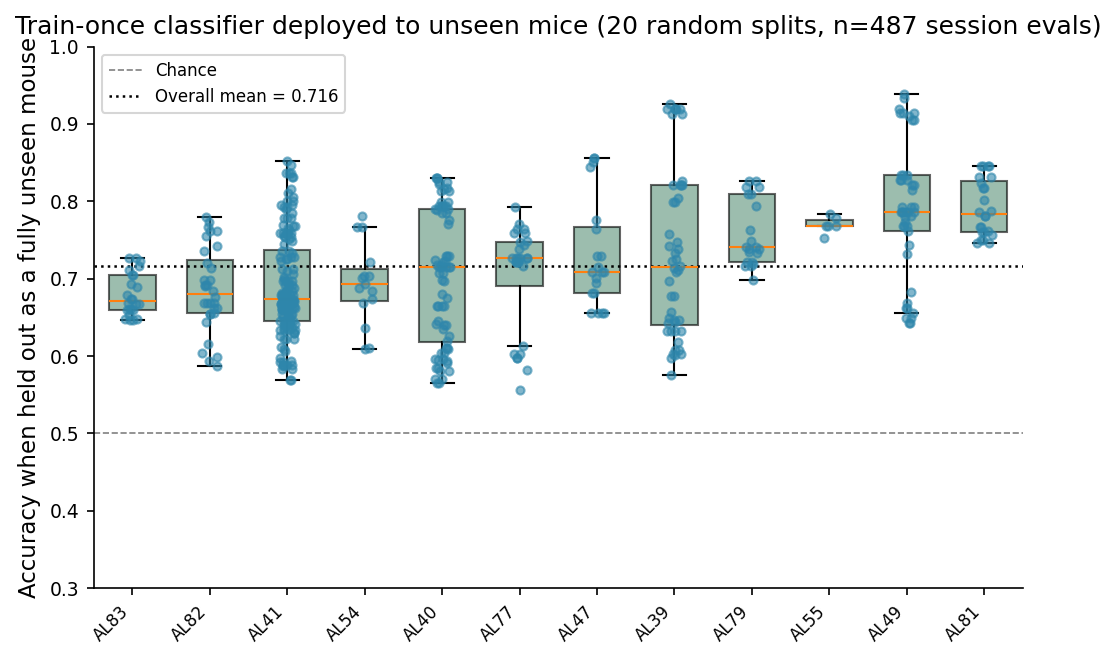


Saved figure: figures/deploy_unseen_mice.png


In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
mice_sorted = sorted(by_mouse, key=lambda m: np.mean(by_mouse[m]))
positions = np.arange(len(mice_sorted))
data = [by_mouse[m] for m in mice_sorted]

bp = ax.boxplot(data, positions=positions, widths=0.6, showfliers=False,
                 patch_artist=True, boxprops=dict(facecolor="#5B9279", alpha=0.6))
for i, vals in enumerate(data):
    jitter = (np.random.default_rng(1).random(len(vals)) - 0.5) * 0.2
    ax.scatter(np.full(len(vals), i) + jitter, vals, color="#2E86AB", alpha=0.6, s=15, zorder=3)

ax.axhline(0.5, ls="--", c="gray", lw=0.8, label="Chance")
ax.axhline(overall_m, ls=":", c="k", lw=1.2, label=f"Overall mean = {overall_m:.3f}")
ax.set_xticks(positions); ax.set_xticklabels(mice_sorted, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Accuracy when held out as a fully unseen mouse")
ax.set_title(f"Train-once classifier deployed to unseen mice ({len(deploy_results)} random splits, "
             f"n={len(all_test_accs)} session evals)")
ax.legend(fontsize=8); ax.set_ylim(0.3, 1.0)
fig.tight_layout()
fig.savefig(f"{FIGDIR}/deploy_unseen_mice.png", dpi=150, bbox_inches="tight")
plt.close(fig)
display(fig)
log("\nSaved figure: figures/deploy_unseen_mice.png")

In [15]:
import shutil
from google.colab import files
shutil.make_archive(FIGDIR, 'zip', FIGDIR)
files.download(f'{FIGDIR}.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>